# Matrix Factorization-Based Method

Given matrix $R$ encoding the user ratings, our goal is to precit ALL the missing ratings.

idea: exploit that there are rows and also columns that are highly dependent- might just need a smaller set of users to describle whole things (basis)

We'll write $R$ as a tall, skinny matrix $U$ times a short fat matrix $V^T$.

predicted rating $\hat{r}_{ij}=$ row $i$ of $U$ $\cdot$ column $J$ of $V^T$ (row $j$ of $V$) = $\sum_{t=1}^ku_{it}v_{it}$.

To find $U$ and $V$, we'll minimize:

$$
\text{error} = \sum_{(i,j)\in S}(r_{ij}-\hat{r}_{ij})^2
$$

With $S=\{(i,j)\text{ such that r_{ij} is not a missing entries}\}$

## Gradient Descent

$U = U-s\cdot \nabla_U\text{error}$

$V = V-s\cdot \nabla_V\text{error}$

### Gradients

$\nabla_U\text{error} = -EV$

$\nabla_V\text{error} = -E^TU$

with error matrix $E = R - UV^T$ where unobserved entries of $E$ are equal to zero
****

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
R = np.array([
    [2, np.nan, 3, np.nan],
    [np.nan, 5, np.nan, 4],
    [1,3,np.nan,5],
    [np.nan,4,2,np.nan]
])
R

array([[ 2., nan,  3., nan],
       [nan,  5., nan,  4.],
       [ 1.,  3., nan,  5.],
       [nan,  4.,  2., nan]])

In [3]:
def matrix_fact(R,k, epochs,learning_rate):
    m,n = R.shape
    
    #number of non-nan ratings
    n_ratings = np.sum(~np.isnan(R))
    
    # initialize U and V
    U = np.random.randn(m,k)
    V = np.random.randn(n,k)
    
    mean_error = np.zeros(epochs)
    
    for epoch in range(epochs):
        # error matrix
        E = R - U.dot(V.T)
        E[np.isnan(E)] = 0
        
        # update U and V
        U,V = U + learning_rate*E.dot(V), V + learning_rate*E.T.dot(U)
        
        mean_error[epoch] = np.sum(E**2)/n_ratings
        
    return U,V,mean_error

In [4]:
def matrix_fact_with_biases(R,k, epochs,learning_rate):
    m,n = R.shape
    
    #number of non-nan ratings
    n_ratings = np.sum(~np.isnan(R))
    
    # initialize U and V
    U = np.random.randn(m,k+2)
    V = np.random.randn(n,k+2)
    U[:,k] = 1
    V[:,k+1] = 1
    
    mean_error = np.zeros(epochs)
    
    for epoch in range(epochs):
        # error matrix
        E = R - U.dot(V.T)
        E[np.isnan(E)] = 0
        
        # update U and V
        U,V = U + learning_rate*E.dot(V), V + learning_rate*E.T.dot(U)
        U[:,k] = 1
        V[:,k+1] = 1
        
        mean_error[epoch] = np.sum(E**2)/n_ratings
        
    return U,V,mean_error

In [5]:
U,V,error = matrix_fact(R,k=2,epochs=50,learning_rate=0.05)

In [6]:
R

array([[ 2., nan,  3., nan],
       [nan,  5., nan,  4.],
       [ 1.,  3., nan,  5.],
       [nan,  4.,  2., nan]])

In [7]:
U.dot(V.T)

array([[1.97571813, 5.30796346, 2.99986022, 6.30158848],
       [1.97003322, 4.99849069, 0.27119565, 4.00255699],
       [1.03271467, 2.99400098, 3.5975259 , 4.99570153],
       [1.50123644, 4.00299328, 1.99995127, 4.55386705]])

In [8]:
# load the movide ratings data
ratings = pd.read_csv('ratings_large.csv')

In [9]:
ratings_matrix = ratings.pivot('title','userId')['rating']

In [10]:
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Theory/master/Data/fake_user.csv'
user = pd.read_csv(url, index_col='title', squeeze=True)

In [11]:


# add fake user to the ratings matrix
ratings_matrix['user'] = user
ratings_matrix



userId,4,19,42,43,51,55,56,71,73,79,...,283164,283165,283170,283183,283184,283185,283195,283204,283224,user
title,,,,,,,,,,,,,,,,,,,,,
(500) Days of Summer (2009),NaN,NaN,4.0,NaN,NaN,NaN,NaN,2.5,4.5,NaN,...,NaN,NaN,4.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN
10 Things I Hate About You (1999),NaN,NaN,NaN,NaN,NaN,1.5,NaN,NaN,NaN,4.0,...,NaN,4.5,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN
101 Dalmatians (1996),NaN,NaN,4.0,NaN,NaN,NaN,0.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101 Dalmatians (One Hundred and One Dalmatians) (1961),NaN,NaN,NaN,NaN,NaN,3.5,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.0,4.5,NaN,NaN,NaN
12 Angry Men (1957),1.5,5.0,NaN,4.5,5.0,NaN,4.0,NaN,NaN,NaN,...,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zoolander (2001),NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,2.5,NaN,...,NaN,NaN,NaN,NaN,2.0,NaN,3.5,NaN,NaN,NaN
Zootopia (2016),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
eXistenZ (1999),3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
R = ratings_matrix.to_numpy()
R.shape

(1344, 35290)

In [13]:
U,V,mean_error = matrix_fact_with_biases(R,k=20,epochs=50,learning_rate = 0.00005)

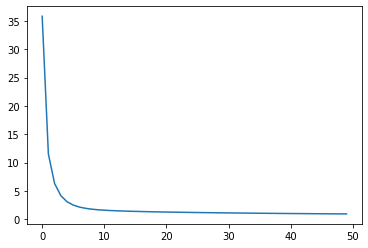

In [14]:
plt.plot(mean_error)

In [15]:
# predictions
R_pred = U.dot(V.T)

In [16]:
user_pred = pd.Series(data = R_pred[:,-1], index=user.index)
user_pred

title
(500) Days of Summer (2009)                               2.289083
10 Things I Hate About You (1999)                         1.979750
101 Dalmatians (1996)                                     1.493879
101 Dalmatians (One Hundred and One Dalmatians) (1961)    2.022104
12 Angry Men (1957)                                       2.849383
                                                            ...   
Zoolander (2001)                                          1.782475
Zootopia (2016)                                           2.462049
eXistenZ (1999)                                           1.964413
xXx (2002)                                                1.283270
¡Three Amigos! (1986)                                     1.716967
Length: 1344, dtype: float64

In [17]:
# top 20 recommendations
user_pred[user.isna()].sort_values(ascending=False).head(20)

title
Usual Suspects, The (1995)                                                        2.897352
Seven Samurai (Shichinin no samurai) (1954)                                       2.882167
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)       2.853612
12 Angry Men (1957)                                                               2.849383
Rear Window (1954)                                                                2.840841
Third Man, The (1949)                                                             2.829559
Casablanca (1942)                                                                 2.827222
M (1931)                                                                          2.821068
One Flew Over the Cuckoo's Nest (1975)                                            2.820468
Touch of Evil (1958)                                                              2.816832
North by Northwest (1959)                                                         2.